# Entrenar una red neuronal que de la solución de las siguientes ecuaciones diferenciales en el el intervalo [-5,5]. Graficar la solución numérica junto con la solución analítica. 

# $(a) xy′ + y = x^2 cos(x)$ con $y(0) = 0$

# $(b) \frac{d^2y}{dx^2} = −y$ con $y(0) = 1, y'(0) = −0.5$

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, metrics, Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from keras.optimizers import Adam
import numpy as np

## $(a) xy′ + y - x^2 cos(x) = 0$, con $y(0) = 0$

In [34]:
class SolucionadorODE_a(Sequential):
    def __init__(self,layers=None, name=None):
        super().__init__(layers=layers, name=name)
        self.loss_tracker = metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        if isinstance(data, (tuple, list)):
            x = data[0]
        else:
            x = data

        batch_size = tf.shape(x)[0]

        with tf.GradientTape() as tape_w:
            with tf.GradientTape() as tape_x:
                tape_x.watch(x)
                y_pred = self(x, training=True)
            dy = tape_x.gradient(y_pred, x) #dy/dx
            x_o = tf.zeros((batch_size,1)) #valor de x en condicion inicial x_0=0
            y_o_pred = self(x_o,training=True) #valor del modelo en x_0
            eq = x*dy+y_pred -tf.math.cos(x)*x**2
            y_o = 0 #Valor real en y(0) = 0
            loss_ode = tf.reduce_mean(tf.square(eq)) 
            loss_ic = tf.reduce_mean(tf.square(y_o_pred - y_o))
            loss = loss_ode + loss_ic

        grads = tape_w.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

In [35]:
model = SolucionadorODE_a()
model.add(Dense(100, activation='tanh', input_shape=(1,)))
model.add(Dense(300, activation='tanh'))
model.add(Dense(1))
model.summary()

/home/dracdarktime/miniconda3/envs/tensorflow-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "solucionador_ode_a_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 300)            │        30,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,801 (120.32 KB)

 Trainable params: 30,801 (120.32 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(Adam(learning_rate=0.0001),metrics=['loss'])
num_muestras = 1000
x = tf.random.uniform((num_muestras,1), minval=-5, maxval=5)
history = model.fit(x,epochs=1000,verbose=0, batch_size=64)

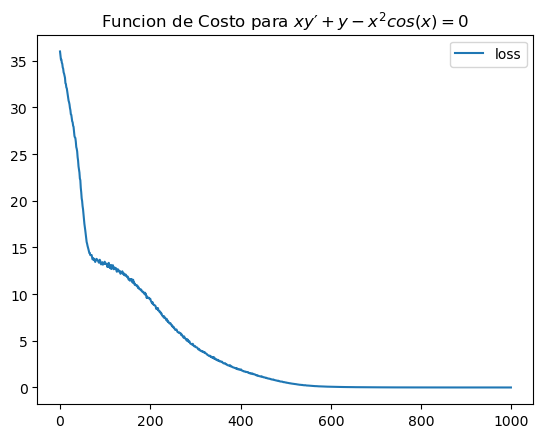

In [37]:
plt.plot(history.history["loss"], label='loss')
plt.title(r"Funcion de Costo para $xy′ + y - x^2 cos(x) = 0$")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


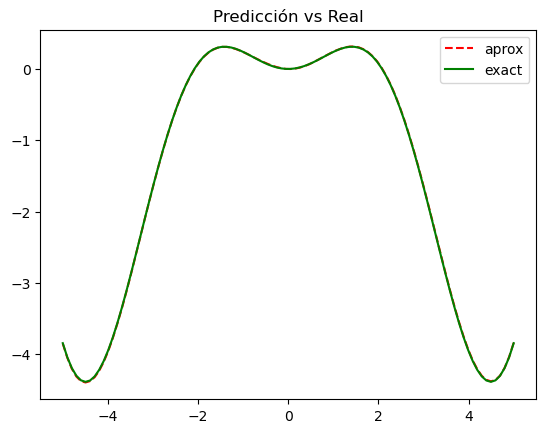

In [38]:
x=tf.linspace(-5,5,100)
y_pred=model.predict(x)
plt.plot(x,y_pred,label="aprox", color='red', linestyle='--')
plt.plot(x,x*tf.math.sin(x) + 2.*tf.math.cos(x) - 2.*tf.math.sin(x)/x,label="exact", color='green')
plt.title("Predicción vs Real")
plt.legend()
plt.show()

## $(b) \frac{d^2y}{dx^2} + y=0$, con $y(0) = 1, y'(0) = −0.5$

In [44]:
class SolucionadorODE_b(Sequential):
    def __init__(self,layers=None, name=None):
        super().__init__(layers=layers, name=name)
        self.loss_tracker = metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        if isinstance(data, (tuple, list)):
            x = data[0]
        else:
            x = data

        batch_size = tf.shape(x)[0]

        x_o = tf.zeros((batch_size,1)) #valor de x en condicion inicial x_0=0

        with tf.GradientTape() as tape_w:
            with tf.GradientTape() as tape_xx:
                tape_xx.watch(x)
                with tf.GradientTape(persistent=True) as tape_x:
                    tape_x.watch(x)
                    tape_x.watch(x_o)
                    y_pred = self(x, training=True)
                    y_o_pred = self(x_o, training=True)#valor del modelo en x_0
                    dy = tape_x.gradient(y_pred, x) #dy/dx

                ddy = tape_xx.gradient(dy,x) #ddy/ddx
                dy_o_pred = tape_x.gradient(y_o_pred, x_o)#valor predicho y'(0)
                del tape_x # liberamos memoria al eliminar el grafo por pesistent=true

            y_o = 1.0 #Valor real en y(0) = 0.0
            dy_o = -0.5 # Valor real en y'(0) = -0.5
            eq = ddy + y_pred
            loss_ode = tf.reduce_mean(tf.square(eq)) 
            loss_ic1 = tf.reduce_mean(tf.square(y_o_pred - y_o))
            loss_ic2 = tf.reduce_mean(tf.square(dy_o - dy_o_pred))
            loss = loss_ode + loss_ic1 + loss_ic2

        grads = tape_w.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

In [49]:
model_b = SolucionadorODE_b()
model_b.add(Dense(100, activation='tanh', input_shape=(1,)))
model_b.add(Dense(300, activation='tanh'))
model_b.add(Dense(1))
model_b.summary()

Model: "solucionador_ode_b_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 300)            │        30,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,801 (120.32 KB)

 Trainable params: 30,801 (120.32 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model_b.compile(Adam(learning_rate=0.0001),metrics=['loss'])
num_muestras = 5000
x = tf.random.uniform((num_muestras,1), minval=-5, maxval=5)
history = model_b.fit(x,epochs=1000,verbose=0, batch_size=64)

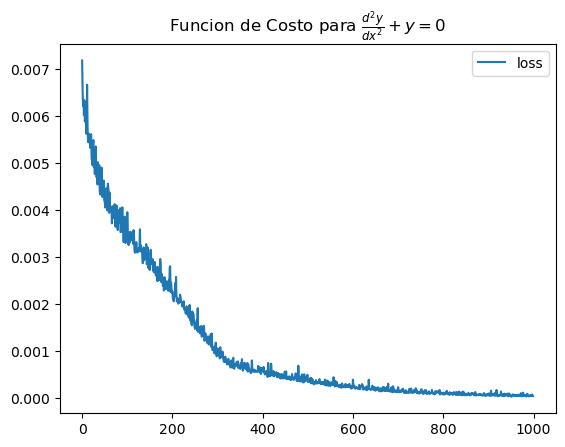

In [54]:
plt.plot(history.history["loss"], label='loss')
plt.title(r"Funcion de Costo para $\frac{d^2y}{dx^2} + y=0$")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


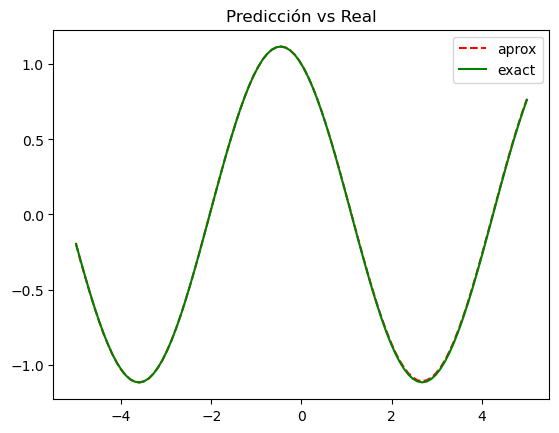

In [55]:
x=tf.linspace(-5,5,100)
y_pred=model_b.predict(x)
plt.plot(x,y_pred,label="aprox", color='red', linestyle='--')
plt.plot(x, np.cos(x) - (1./2.)*np.sin(x),label="exact", color='green')
plt.title("Predicción vs Real")
plt.legend()
plt.show()